## Plot longitudinal trend in Kaoma

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

In [17]:
# Global font size parameters -- aim to produce plots at correct size
mpl.rcParams['font.size'] = 8  # base font size
# mpl.rcParams['axes.titlesize'] = 16
# mpl.rcParams['axes.labelsize'] = 14
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 12
# mpl.rcParams['figure.titlesize'] = 18

## Settings

In [18]:
W = 3.4
save_results = True
DIR_FIG = "../figures/fig3"
os.makedirs(DIR_FIG, exist_ok=True)

## Load data

In [19]:
df = pd.read_csv("../seqdata/all/summaries/longitudinal_kaoma/summary.variants.prevalence-year.csv")

In [20]:
df_a7 = df.query("aa_change == 'A724E'")
df_a7 = df_a7.sort_values("year")

## Plot

In [21]:
COL = sns.color_palette("Spectral", 10)[0]

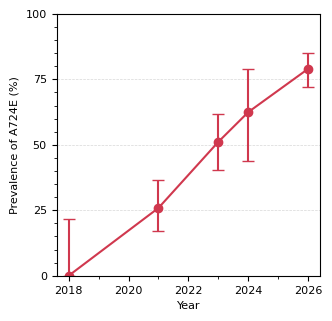

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(W, W))

ax.errorbar(x=df_a7['year'],
            y=df_a7['prevalence'],
            yerr=[df_a7['prevalence'] - df_a7['prevalence_lowci'], df_a7['prevalence_highci'] - df_a7['prevalence']],
            marker='o',
            capsize=4,
            color=COL
           )

ax.set_ylim(0, 100)
# ax.yaxis.set_major_locator(plt.MultipleLocator(10))
# ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
# Lines
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(plt.MultipleLocator(25))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(axis='y', lw=0.5, ls='dashed', alpha=0.5)
#ax.grid(ls='solid', axis='y', alpha=0.5)
#ax.grid(ls='dashed', axis='y', which='minor', alpha=0.5)
#ax.set_title("$kelch13$ A724E, Kaoma", loc='left')
ax.set_ylabel("Prevalence of A724E (%)")
ax.set_xlabel("Year")

if False:
    for _, row in df_a7.iterrows():
        ax.annotate(xy=(row['year']+0.3, row['prevalence']),
                    text=f"{row['prevalence']:.1f}% ({int(row['n_mixed'] + row['n_mut']):d}/{int(row['n_passed']):d})",
                    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", lw=0.5)
                   )

if save_results:
    fig.savefig("../figures/fig3/plot.longitudinal.pdf", dpi=300, bbox_inches="tight", pad_inches=0.2)
    fig.savefig("../figures/fig3/plot.longitudinal.png", dpi=600, bbox_inches="tight", pad_inches=0.2)

In [23]:
mutation_column_names = {
    "year": "Year",
    "prevalence_table": "Prevalence (95% CI) $-$ %",
    "n_passed": "N",
    "n_mut": "Mutant $-$ n",
    "n_mixed": "Mixed $-$ n",
    "n_total": "Mutant or Mixed $-$ n"
}

In [24]:
def annotate_for_manuscript(df: pd.DataFrame) -> pd.DataFrame:
    # Annotations
    df_geography = df.copy()
    df_geography['n_total'] = df_geography['n_mut'] + df_geography['n_mixed']
    df_geography["prevalence_table"] = [
        f"{r['prevalence']:.1f} ({r['prevalence_lowci']:.1f}-{r['prevalence_highci']:.1f})"
        for _, r in df_geography.iterrows()
    ]
    for c in ['n_total', 'n_mut', 'n_mixed']:
        df_geography[c] = df_geography[c].astype(int)
    
    return df_geography

In [25]:
df_longitudinal = annotate_for_manuscript(df_a7)[["year", "prevalence_table", "n_passed", "n_mixed", "n_mut", "n_total", ]]
df_longitudinal = df_longitudinal.rename(mutation_column_names, axis=1).reset_index(drop=True)

In [26]:
df_longitudinal

,Year,Prevalence (95% CI) $-$ %,N,Mixed $-$ n,Mutant $-$ n,Mutant or Mixed $-$ n
0,2018,0.0 (0.0-21.8),15,0,0,0
1,2021,25.9 (17.0-36.5),85,11,11,22
2,2023,51.1 (40.2-61.9),88,26,19,45
3,2024,62.5 (43.7-78.9),32,14,6,20
4,2026,79.0 (72.1-84.9),167,79,53,132


In [27]:
if save_results:
    df_longitudinal.to_csv("../tables/stable_longitudinal.csv")
    df_longitudinal.to_excel("../tables/stable_longitudinal.xlsx")

## Version matching Figure 1

In [28]:
df_plot = df_a7

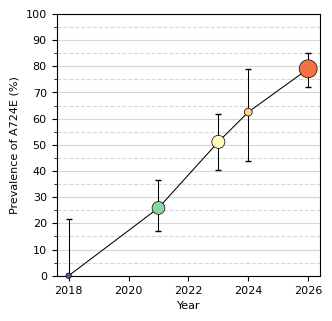

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(W, W))

ax.scatter(
    x="year",
    y="prevalence",
    s="n_passed",
    c="prevalence",
    cmap="Spectral_r",
    vmin=0, vmax=100,
    ec='black', lw=0.5,
    clip_on=False,
    #color='black',
    zorder=10,
    data=df_plot,
)

ax.errorbar(x=df_plot["year"],
            y=df_plot["prevalence"],
            fmt='-',
            yerr=(df_plot["prevalence"] - df_plot['prevalence_lowci'], 
                  df_plot['prevalence_highci'] - df_plot["prevalence"]),
            color='black',
            lw=0.75,
            capsize=2
           )

# Limits
ax.set_ylim(0, 100)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.grid(ls='solid', axis='y', alpha=0.5)
ax.grid(ls='dashed', axis='y', which='minor', alpha=0.5)
#ax.set_title("$kelch13$ A724E, Kaoma", loc='left')
ax.set_ylabel("Prevalence of A724E (%)")
ax.set_xlabel("Year")

if False:
    for _, row in df_a7.iterrows():
        ax.annotate(xy=(row['year']+0.3, row['prevalence']),
                    text=f"{row['prevalence']:.1f}% ({int(row['n_mixed'] + row['n_mut']):d}/{int(row['n_passed']):d})",
                    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", lw=0.5)
                   )


if save_results:
    fig.savefig(f"{DIR_FIG}/plot.longitudinal.match.pdf", dpi=300, bbox_inches="tight", pad_inches=0.2)
    fig.savefig(f"{DIR_FIG}/plot.longitudinal.match.png", dpi=600, bbox_inches="tight", pad_inches=0.2)

In [30]:
df_plot

,gene,chrom,aa_pos,aa_change,mut_type,mutation,year,n_mixed,n_mut,n_samples,n_passed,n_wt,per_wt,per_mixed,per_mut,prevalence,prevalence_lowci,prevalence_highci
78,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2018,0.0,0.0,15,15,15,100.000000,0.000000,0.000000,0.000000,0.000000,21.801936
394,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2021,11.0,11.0,85,85,63,74.117647,12.941176,12.941176,25.882353,16.985049,36.523562
315,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2023,26.0,19.0,88,88,43,48.863636,29.545455,21.590909,51.136364,40.245608,61.948481
235,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2024,14.0,6.0,32,32,12,37.500000,43.750000,18.750000,62.500000,43.692246,78.899968
157,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2026,79.0,53.0,167,167,35,20.958084,47.305389,31.736527,79.041916,72.077129,84.946586


### Empirical rate of increase

In [31]:
estimated_annual_change = df_a7["prevalence"].diff() / df_a7["year"].diff()
estimated_annual_change.index = df_a7["year"]
estimated_annual_change

year
2018          NaN
2021     8.627451
2023    12.627005
2024    11.363636
2026     8.270958
dtype: float64

In [32]:
estimated_annual_change.describe()

count     4.000000
mean     10.222263
std       2.116328
min       8.270958
25%       8.538328
50%       9.995544
75%      11.679479
max      12.627005
dtype: float64

- A mean rate of increase of 10.2%
- A median of 10%
- In a way, we are just calculating a mean, and we have now standard deviations
- We could treat this as a $\bar{X}$, and make the asymptomatic assumption of normality, and estimate with Wald's interval

In [33]:
n, mu, std = estimated_annual_change.describe()[['count', 'mean', 'std']]
se = std / np.sqrt(n)
print(f"We estimate a mean rate of increase of {mu:.1f}% ({mu-se*1.96:.1f} to {mu+se*1.96:.1f}%).")

We estimate a mean rate of increase of 10.2% (8.1 to 12.3%).


In [34]:
print(f"We estimate a mean rate of increase of {mu:.1f}% ({mu-se*1.96:.1f} to {mu+se*1.96:.1f}%).")

We estimate a mean rate of increase of 10.2% (8.1 to 12.3%).


- But really, we only have four data points, so this asymptotic assumption probably bad.

"The prevalence of A724E increased, in absolute terms, by an average of 10.2% between 2018 through 2026."

## Modelling the trend

### GLM with binomial likelihood and logit link function

e.g. 

```
log(p/(1-p) = -t0s + ts
```

In [35]:
# Prepare data
y = df_a7["prevalence"] / 100
X = sm.add_constant(df_a7["year"])
n = df_a7["n_passed"]

In [36]:
X

,const,year
78,1.0,2018
394,1.0,2021
315,1.0,2023
235,1.0,2024
157,1.0,2026


In [37]:
# Fit
model = sm.GLM(y, X, family=sm.families.Binomial(), var_weights=n).fit()

In [38]:
# Summarise
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             prevalence   No. Observations:                    5
Model:                            GLM   Df Residuals:                        3
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -146.48
Date:                Mon, 24 Aug 2026   Deviance:                       2.8201
Time:                        20:02:01   Pearson chi2:                     1.71
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -993.8201    116.155     -8.556      0.0

In [39]:
188*7

1316

In [40]:
print(model.summary2())

              Results: Generalized linear model
Model:              GLM              AIC:            296.9598
Link Function:      Logit            BIC:            -2.0082 
Dependent Variable: prevalence       Log-Likelihood: -146.48 
Date:               2026-08-24 20:02 LL-Null:        -193.46 
No. Observations:   5                Deviance:       2.8201  
Df Model:           1                Pearson chi2:   1.71    
Df Residuals:       3                Scale:          1.0000  
Method:             IRLS                                     
-------------------------------------------------------------
         Coef.   Std.Err.    z    P>|z|    [0.025     0.975] 
-------------------------------------------------------------
const  -993.8201 116.1550 -8.5560 0.0000 -1221.4798 -766.1604
year      0.4912   0.0574  8.5582 0.0000     0.3787    0.6037



In [41]:
# What are some useful goodness of fit statistics?

In [42]:
model.resid_deviance

78    -1.519703
394   -0.001384
315    0.538216
235    0.244319
157   -0.401598
dtype: float64

In [43]:
alpha_hat, s_hat = model.params
t0_hat = -alpha_hat / s_hat

In [44]:
s_hat, t0_hat

(0.4912263187053947, 2023.1410693029932)

In [45]:
- model.conf_int().loc['const'] / s_hat

0    2486.592834
1    1559.689304
Name: const, dtype: float64

In [46]:
cov = model.cov_params()

# gradient of t0 = -alpha / s
grad = np.array([
    -1 / s_hat,              # derivative wrt alpha
    alpha_hat / s_hat**2     # derivative wrt s
])

# delta-method variance
var_t0 = grad @ cov @ grad
se_t0 = np.sqrt(var_t0)

# 95% CI
ci_t0 = (
    t0_hat - 1.96 * se_t0,
    t0_hat + 1.96 * se_t0
)

print("t0 estimate:", t0_hat)
print("SE(t0):", se_t0)
print("95% CI for t0:", ci_t0)

t0 estimate: 2023.1410693029932
SE(t0): 0.24552858571861788
95% CI for t0: (np.float64(2022.6598332749847), np.float64(2023.6223053310016))


- Fine, seems reasonable

In [47]:
t_pred = np.linspace(2014, 2030, 100)
p_pred = model.get_prediction(sm.add_constant(t_pred)).summary_frame()
t_year = np.arange(2014, 2030+1)
p_year = model.predict(sm.add_constant(t_year))

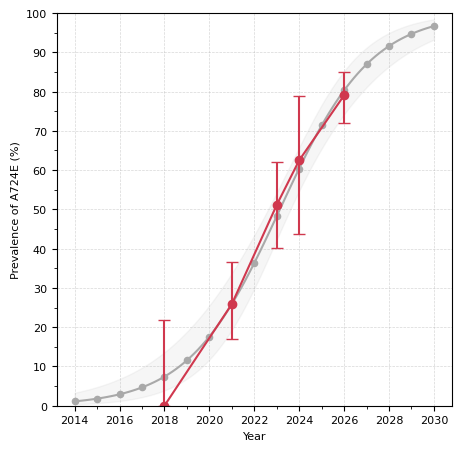

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(W*1.5, W*1.5))

# Model plot
ax.plot(t_pred, 
        p_pred["mean"]*100,
        color='darkgrey')
ax.fill_between(t_pred, 100*p_pred["mean_ci_lower"], 100*p_pred["mean_ci_upper"], alpha=0.1, color='darkgrey')
ax.scatter(t_year, 
           p_year*100,
           s=20,
           color='darkgrey')

# Data
ax.errorbar(x=df_a7['year'],
            y=df_a7['prevalence'],
            yerr=[df_a7['prevalence'] - df_a7['prevalence_lowci'], df_a7['prevalence_highci'] - df_a7['prevalence']],
            marker='o',
            capsize=4,
            color=COL
           )

ax.set_ylim(0, 100)
# Lines
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(axis='y', lw=0.5, ls='dashed', alpha=0.5)
#ax.grid(ls='solid', axis='y', alpha=0.5)
ax.grid(axis='x', lw=0.5, ls='dashed', alpha=0.5)
#ax.grid(ls='dashed', axis='y', which='minor', alpha=0.5)
#ax.set_title("$kelch13$ A724E, Kaoma", loc='left')
ax.set_ylabel("Prevalence of A724E (%)")
ax.set_xlabel("Year")

if save_results:
    fig.savefig(f"{DIR_FIG}/plot.longitudinal_modelled.pdf", dpi=300, bbox_inches="tight", pad_inches=0.2)
    fig.savefig(f"{DIR_FIG}/plot.longitudinal_modelled.png", dpi=600, bbox_inches="tight", pad_inches=0.2)

In [49]:
(1 - p_year[4])**15

np.float64(0.31513659355778767)

We fit a generalised-linear model with a logit link function and binomial likelihood to the A724 prevalence data. 

### Sensitivity

In [50]:
df_a7_sens = df_a7.query("year != 2018")

In [51]:
# Prepare data
ys = df_a7_sens["prevalence"] / 100
Xs = sm.add_constant(df_a7_sens["year"])
ns = df_a7_sens["n_passed"]

In [52]:
# Fit
model_sens = sm.GLM(ys, Xs, family=sm.families.Binomial(), var_weights=ns).fit()

In [53]:
# Summarise
print(model_sens.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             prevalence   No. Observations:                    4
Model:                            GLM   Df Residuals:                        2
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -145.24
Date:                Mon, 24 Aug 2026   Deviance:                      0.34389
Time:                        20:02:14   Pearson chi2:                    0.343
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -946.5900    121.449     -7.794      0.0

### Evaluation that of the predictor being linear

In [54]:
df_a7

,gene,chrom,aa_pos,aa_change,mut_type,mutation,year,n_mixed,n_mut,n_samples,n_passed,n_wt,per_wt,per_mixed,per_mut,prevalence,prevalence_lowci,prevalence_highci
78,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2018,0.0,0.0,15,15,15,100.000000,0.000000,0.000000,0.000000,0.000000,21.801936
394,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2021,11.0,11.0,85,85,63,74.117647,12.941176,12.941176,25.882353,16.985049,36.523562
315,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2023,26.0,19.0,88,88,43,48.863636,29.545455,21.590909,51.136364,40.245608,61.948481
235,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2024,14.0,6.0,32,32,12,37.500000,43.750000,18.750000,62.500000,43.692246,78.899968
157,kelch13,Pf3D7_13_v3,724,A724E,missense,kelch13-A724E,2026,79.0,53.0,167,167,35,20.958084,47.305389,31.736527,79.041916,72.077129,84.946586


/Users/u_hendry/miniforge3/envs/nomadic-dev/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0, 0.5, 'logit(p)')

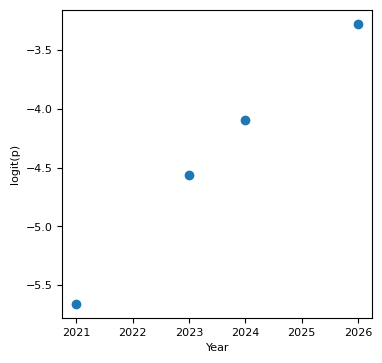

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(
    x=df_a7['year'],
    y=np.log((1/100) * (df_a7['prevalence'] / (100 - df_a7['prevalence'])))
)
ax.set_xlabel("Year")
ax.set_ylabel("logit(p)")

## GLM with identity fit
- We will test hte fit against a linear model
- And compare the two models using the AIC

In [56]:
X_identity = X.copy()
X_identity['year'] = X_identity['year'] - X_identity['year'].median() # we normalise the years for stability

In [57]:
model_identity = sm.GLM(
    y, X_identity,
    family=sm.families.Binomial(link=sm.families.links.Identity()),
    var_weights=n
).fit()

/Users/u_hendry/miniforge3/envs/nomadic-dev/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Binomial family.
  warnings.warn((f"The {type(family.link).__name__} link function "


In [58]:
print(model_identity.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             prevalence   No. Observations:                    5
Model:                            GLM   Df Residuals:                        3
Model Family:                Binomial   Df Model:                            1
Link Function:               Identity   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -145.49
Date:                Mon, 24 Aug 2026   Deviance:                      0.83434
Time:                        20:02:18   Pearson chi2:                    0.817
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4946      0.017     28.326      0.0

In [59]:
model_identity.params, model_identity.conf_int()

(const    0.494636
 year     0.098927
 dtype: float64,
               0         1
 const  0.460411  0.528861
 year   0.092082  0.105772)

In [60]:
mu = 100 * model_identity.params["year"]
ci_low, ci_high = 100 * model_identity.conf_int(alpha=0.05).loc["year"]

In [61]:
print(f"We estimate a mean rate of increase of {mu:.1f}% ({ci_low:.1f} to {ci_high:.1f}%).")

We estimate a mean rate of increase of 9.9% (9.2 to 10.6%).


In [62]:
t_pred = np.linspace(2014, 2030, 100)
p_pred = model_identity.get_prediction(sm.add_constant(t_pred - X['year'].median())).summary_frame()
t_year = np.arange(2014, 2030+1)
p_year = model_identity.predict(sm.add_constant(t_year - X['year'].median()))

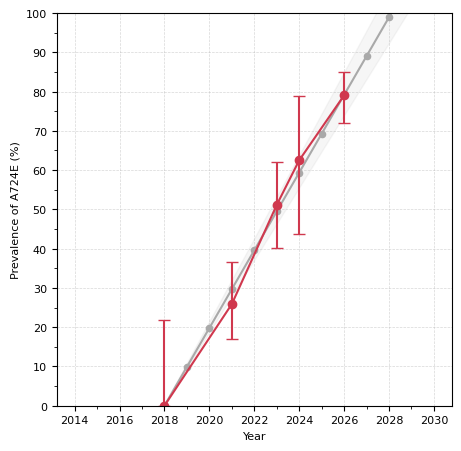

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(W*1.5, W*1.5))

# Model plot
ax.plot(t_pred, 
        p_pred["mean"]*100,
        color='darkgrey')
ax.fill_between(t_pred, 100*p_pred["mean_ci_lower"], 100*p_pred["mean_ci_upper"], alpha=0.1, color='darkgrey')
ax.scatter(t_year, 
           p_year*100,
           s=20,
           color='darkgrey')

#ax.plot(t_year, 100*(model_identity.params[0] + t_year*model_identity.params[1]))

# Data
ax.errorbar(x=df_a7['year'],
            y=df_a7['prevalence'],
            yerr=[df_a7['prevalence'] - df_a7['prevalence_lowci'], df_a7['prevalence_highci'] - df_a7['prevalence']],
            marker='o',
            capsize=4,
            color=COL
           )

ax.set_ylim(0, 100)
# Lines
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(axis='y', lw=0.5, ls='dashed', alpha=0.5)
#ax.grid(ls='solid', axis='y', alpha=0.5)
ax.grid(axis='x', lw=0.5, ls='dashed', alpha=0.5)
#ax.grid(ls='dashed', axis='y', which='minor', alpha=0.5)
#ax.set_title("$kelch13$ A724E, Kaoma", loc='left')
ax.set_ylabel("Prevalence of A724E (%)")
ax.set_xlabel("Year")

if save_results:
    fig.savefig(f"{DIR_FIG}/plot.longitudinal_modelled.linear.pdf", dpi=300, bbox_inches="tight", pad_inches=0.2)
    fig.savefig(f"{DIR_FIG}/plot.longitudinal_modelled.linear.png", dpi=600, bbox_inches="tight", pad_inches=0.2)

In [64]:
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             prevalence   No. Observations:                    5
Model:                            GLM   Df Residuals:                        3
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -146.48
Date:                Mon, 24 Aug 2026   Deviance:                       2.8201
Time:                        20:02:25   Pearson chi2:                     1.71
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -993.8201    116.155     -8.556      0.0

In [65]:
model.aic

np.float64(296.95978271535273)

In [66]:
model_identity.aic

np.float64(294.9739755148615)

In [67]:
model.aic

np.float64(296.95978271535273)

In [68]:
model_identity.aic - model.aic

np.float64(-1.9858072004912515)